In [173]:
import re
import numpy as np
import matplotlib.pyplot as plt
import json
import pandas as pd

In [174]:
#read results.txt and print the results in a table
results = []
with open('results.txt', 'r') as f:
    lines = f.readlines()
    for line in lines:
        #line is in the format "(score as a float,{some dict},time)"
        #we want to extract all 3 values
        #first extract the score
        score = re.findall(r'\d+\.\d+', line)[0]
        time = re.findall(r'\d+\.\d+', line)[-1]
        #now extract the dict by splitting after the first comma and before the last comma
        dict_string = line.split(',',1)[1].rsplit(',',1)[0]
        readable_dict = dict_string.replace("'",'"')
        readable_json = json.loads(readable_dict)
        readable_json['score'] = float(score)
        readable_json['time'] = float(time)
        results.append([score,time,readable_json])

#print the results sorted by score
results = sorted(results, key=lambda k: k[0], reverse=False)
print("Results:")
print("Score\t\tTime\t\tDict")
for result in results:
    print(result[0]+"\t"+result[1]+"\t"+str(result[2]))
        

Results:
Score		Time		Dict
0.0015873642405495048	2912.8394672870636	{'group_size': 25, 'TEST_PROPORTION': 0.2, 'epochs': 1000, 'batch_size': 256, 'output_range': [-1, 1], 'between_layers': 3, 'first_layer_size': 128, 'layer_size_factor': 0.75, 'bottleneck_size': 2, 'num_features': 26, 'bottleneck_activation': 'linear', 'output_activation': 'linear', 'id': 60, 'score': 0.0015873642405495048, 'time': 2912.8394672870636}
0.0016052811406552792	2977.590038537979	{'group_size': 25, 'TEST_PROPORTION': 0.2, 'epochs': 1000, 'batch_size': 256, 'output_range': [-1, 1], 'between_layers': 3, 'first_layer_size': 128, 'layer_size_factor': 0.75, 'bottleneck_size': 2, 'num_features': 26, 'bottleneck_activation': 'tanh', 'output_activation': 'tanh', 'id': 63, 'score': 0.0016052811406552792, 'time': 2977.590038537979}
0.0016135432524606586	2770.6014211177826	{'group_size': 25, 'TEST_PROPORTION': 0.2, 'epochs': 1000, 'batch_size': 256, 'output_range': [-1, 1], 'between_layers': 3, 'first_layer_size': 128,

Constant Params:
group_size : 25
TEST_PROPORTION : 0.2
epochs : 1000
batch_size : 256
output_range : [-1, 1]
bottleneck_size : 2
num_features : 26

Varying Params:
between_layers : [3 2]
first_layer_size : [128 64 32 16]
layer_size_factor : [0.75 0.5]
bottleneck_activation : ['linear' 'tanh']
output_activation : ['linear' 'tanh']


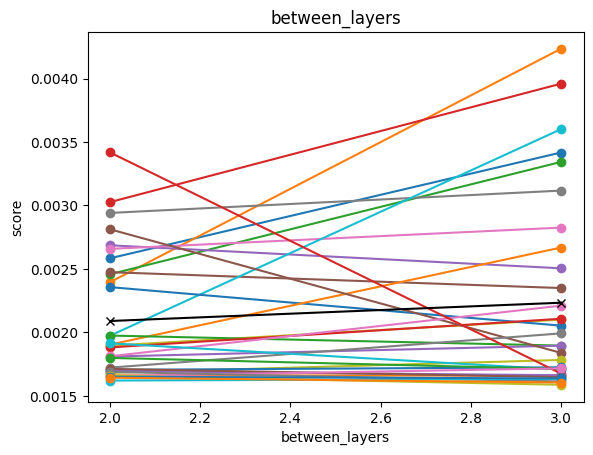

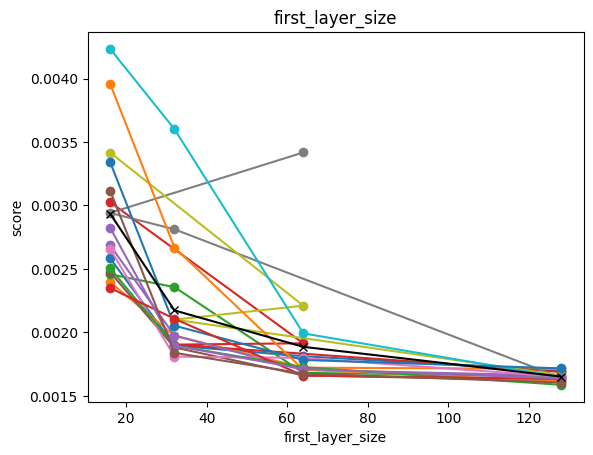

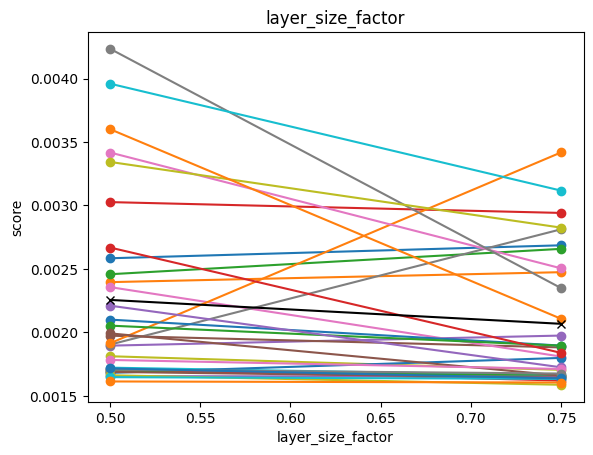

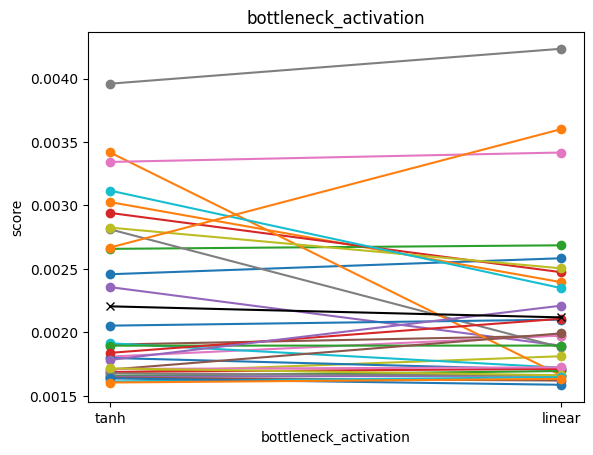

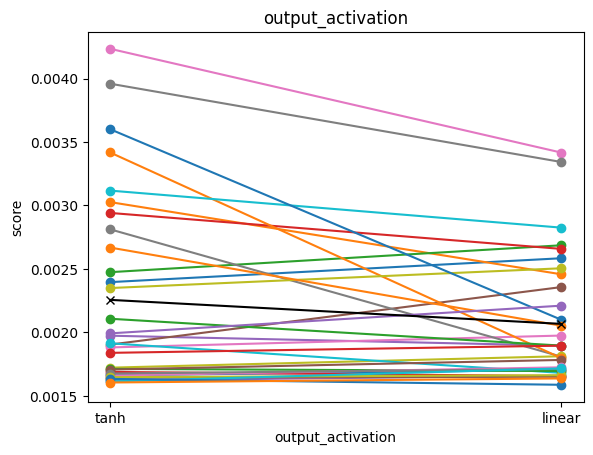

In [175]:
keys = list(results[0][2].keys())
new_data= []
for row in results:
    row_data = []
    for key in keys:
        if(isinstance(row[2][key],list)):
            row_data.append(str(row[2][key]))
        else:
            row_data.append(row[2][key])
    new_data.append(row_data)

data = np.array(new_data,dtype=object)
df = pd.DataFrame(data,columns=keys)
varying_keys = []
non_varying_keys = []
for key in keys:
    if key in ['score','time','id']:
        continue
    if(len(df[key].unique())>1):
        varying_keys.append(key)
    else:
        non_varying_keys.append(key)

all_factors = keys.copy()
all_factors.remove('score')
all_factors.remove('time')
all_factors.remove('id')

print("Constant Params:")
for key in non_varying_keys:
    print(key,":",df[key].unique()[0])
print("")
print("Varying Params:")
for key in varying_keys:
    print(key,":",df[key].unique())

def get_grouped_df(df,factor):
    df_copy = df.copy()
    factors = all_factors.copy()
    factors.remove(factor)
    df_copy = df_copy.groupby(factors)
    plt.figure()
    plt.title(factor)
    plt.xlabel(factor)
    plt.ylabel('score')
    for key, item in df_copy:
        plt.plot(item[factor],item['score'],label=key,marker='o')
    stats_df = df.copy()
    stats_df = stats_df.groupby([factor])
    #for each option for the factor, print the mean and std of the score
    x = []
    y = []
    for key, item in stats_df:
        x.append(key[0])
        y.append(item['score'].mean())
        #what are the possible values for marker?
        #the possible values are listed here: https://matplotlib.org/3.1.1/api/markers_api.html
    plt.plot(x,y,label='mean',marker='x',color='black')
       
    return df_copy


for factor in varying_keys:
    get_grouped_df(df,factor)
